# Boxplot
**1**. Định nghĩa
- Boxplot (biểu đồ hộp) dùng để tóm tắt nhanh phân phối dữ liệu và so sánh các nhóm mà không cần nhìn hết từng số
- Ví dụ: điểm thi 3 lớp A/B/C -> lớp nào median cao hơn, lớp nào chênh lệch điểm lớn hơn, lớp nào có nhiều bạn quá thấp/quá cao
Lương theo phòng ban: phòng nào có lương điển hình cao hơn (ngắn gọn: median, nhìn vào boxplot: vùng Q1 -> Q3) và có outlier lương khủng hay không ?

**2**. Các thành phần của boxplot:
<ol>
    <li>Hộp (Box)
        <ul>
            <li>Cạnh dưới của hộp: Q1 (25% dữ liệu <= Q1)</li>
            <li>Cạnh trên của hộp: Q3 (75% dữ liệu <= Q3)</li>
            <li>Chiều cao của hộp: IQR = Q3 - Q1 (độ phân tán của 50% dữ liệu giữa)</li>
        </ul>
    </li>
    <li>Đường ở giữa hộp
        <ul>
            <li>Median (Q2): trung vị (50% dữ liệu <= median)</li>
        </ul>
    </li>
    <li>Râu (Whiskers)
        <ul>
            <li>Râu dưới: thường kéo đến giá trị nhỏ nhất vẫn còn hợp lệ (không phải outlier)</li>
            <li>Râu trên: tương tự kéo đến giá trị lớn nhất vẫn còn hợp lệ</li>
            <li>Hợp lệ nằm trong đoạn [Q1 - 1.5xIQR, Q3 + 1.5xIQR]</li>
        </ul>
    </li>
    <li>Điểm outlier (ngoại lệ)
        <ul>
            <li>Các điểm nhỏ hơn Q1 - 1.5xIQR hay lớn hơn Q3 + 1.5xIQR</li>
            <li>Hay được vẽ thành chấm nằm ngoài râu</li>
        </ul>
    </li>
</ol>

In [1]:
a_class <- c(6.5,7.0,7.2,7.5,7.8,8.0,8.2,8.5,8.8,9.0, 6.8,7.3,7.6,8.1,8.4,7.9,8.3,7.7,8.6,8.9)

In [2]:
a_class

[1] 6.5 7.0 7.2 7.5 7.8 8.0 8.2 8.5 8.8 9.0 6.8 7.3 7.6 8.1 8.4 7.9 8.3 7.7 8.6
[20] 8.9

In [5]:
sorted_a <- sort(a_class)

In [6]:
sorted_a
# 6.5 6.8 7.0 7.2 7.3 7.5 7.6 7.7 7.8 7.9 8.0 8.1 8.2 8.3 8.4 8.5 8.6 8.8 8.9 9.0
#  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20

[1] 6.5 6.8 7.0 7.2 7.3 7.5 7.6 7.7 7.8 7.9 8.0 8.1 8.2 8.3 8.4 8.5 8.6 8.8 8.9
[20] 9.0

In [7]:
min(sorted_a)

[1] 6.5

In [14]:
quantile(sorted_a, 0.25) # 25%: 7.45
(sorted_a[5] + sorted_a[6])/2

25% 
7.45

[1] 7.4

In [11]:
median(sorted_a) # 7.95
(sorted_a[10] + sorted_a[11])/2

[1] 7.95

[1] 7.95

In [13]:
length(sorted_a) # 20

[1] 20

In [16]:
quantile(sorted_a, 0.75)
(sorted_a[15] + sorted_a[16])/2

75% 
8.425

[1] 8.45

In [17]:
max(sorted_a)

[1] 9

In [19]:
q1 <- quantile(sorted_a, 0.25)
q3 <- quantile(sorted_a, 0.75)
summary <- c(
    min(sorted_a),
    q1,
    median(sorted_a),
    q3,
    max(sorted_a)
)

summary

25%         75%       
6.500 7.450 7.950 8.425 9.000

In [20]:
iqr <- q3 - q1
iqr

75% 
0.975

In [21]:
lower_fence <- q1 - 1.5*iqr
lower_fence

25% 
5.9875

In [22]:
upper_fence <- q3 + 1.5*iqr
upper_fence

75% 
9.8875

In [23]:
sorted_a

[1] 6.5 6.8 7.0 7.2 7.3 7.5 7.6 7.7 7.8 7.9 8.0 8.1 8.2 8.3 8.4 8.5 8.6 8.8 8.9
[20] 9.0

In [24]:
a_class <- c(6.5,7.0,7.2,7.5,7.8,8.0,8.2,8.5,8.8,9.0, 6.8,7.3,7.6,8.1,8.4,7.9,8.3,7.7,8.6,8.9)

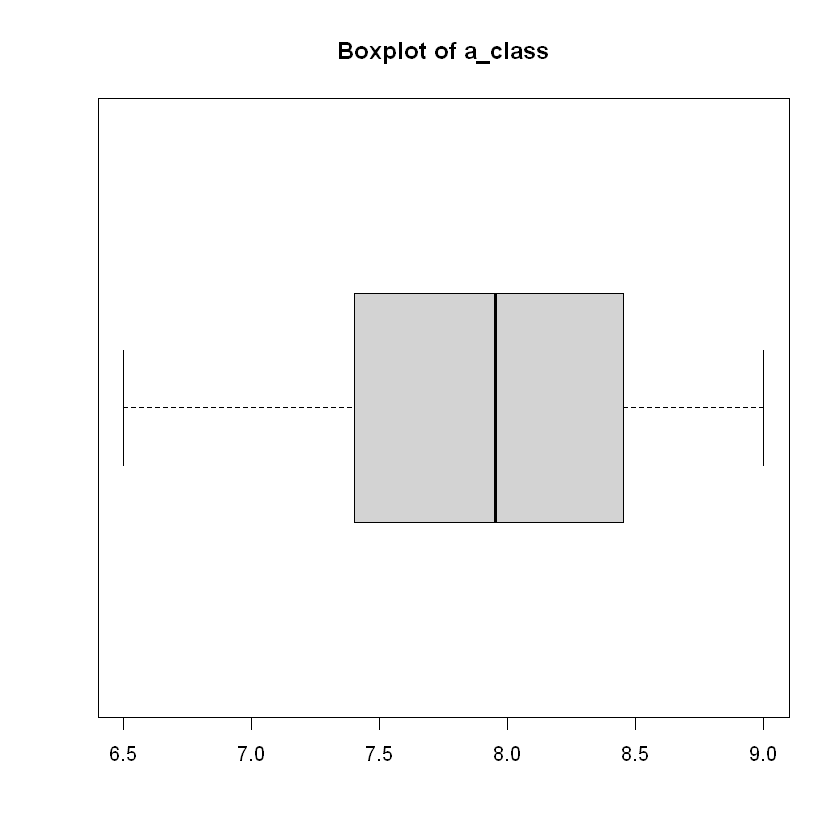

In [25]:
boxplot(
    a_class,
    horizontal = TRUE,
    main = "Boxplot of a_class"
)

In [26]:
summary(a_class)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  6.500   7.450   7.950   7.905   8.425   9.000 

In [27]:
fivenum(a_class)

[1] 6.50 7.40 7.95 8.45 9.00

In [28]:
boxplot.stats(a_class)$out

numeric(0)

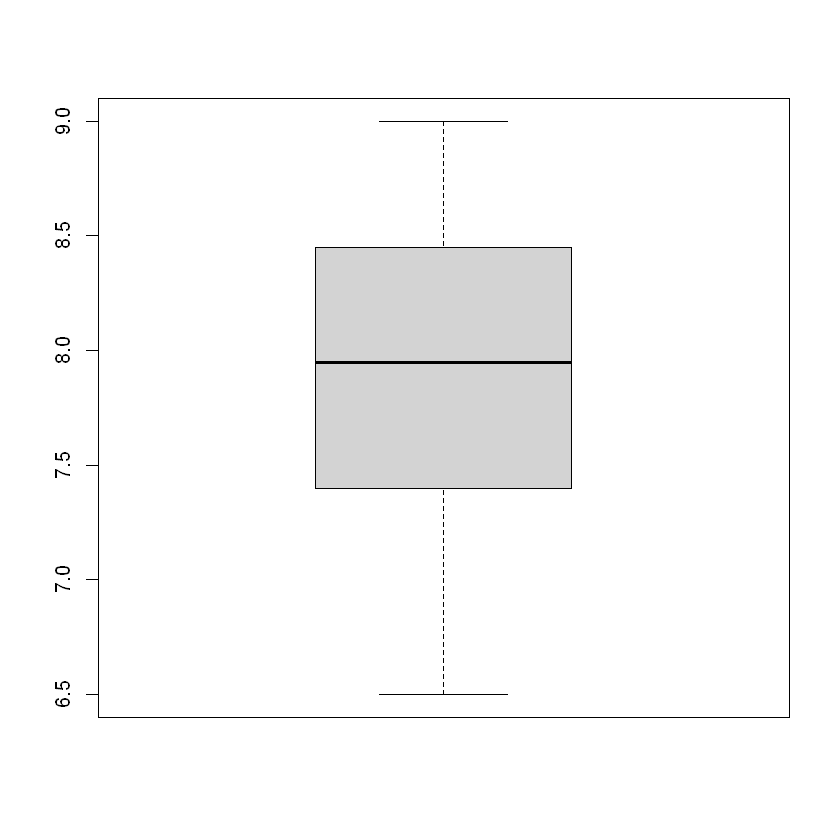

In [30]:
boxplot(a_class)

# Làm thế nào để biết dữ liệu lệch trái hay lệch phải thậm chí là cân bằng ?
## I. **Nhìn boxplot** (nhanh nhất)
1. **Lệch phải** (right_skew, đuôi dài bên phải)
   - Râu trên dài hơn râu dưới
   - Median nằm gần Q1 (lệch về phía dưới của hộp)
   - Thường có outlier phía lớn
     => Kéo dài về phía số lớn = lệch phải
2. **Lệch trái** (left-skew, đuôi dài bên trái)
   - Râu dưới dài hơn râu trên
   - Median nằm gần Q3
   - Thường có outlier phía nhỏ
     => kéo dài về phía số nhỏ = lệch trái
3. **Cân bằng** (xấp xỉ đối xứng)
   - Hai râu gần bằng nhau
   - Median nằm giữa hộp
   - Khoảng **Q1** <-> **Median** xấp xỉ **Median** <-> **Q3**
## II. So sánh Mean và Median (rất phổ biến)
- Mean > Median => Thường **lệch phải**
- Mean < Median => Thường **lệch trái**
- Mean = Median => Thường **khá cân bằng**
- Vì mean bị kéo về phía đuôi dài
## III. Tính hệ số lệch (skewness) trong R (định lượng)
1. skewness > 0 => lệch phải
2. skewness < 0 => lệch trái
3. gần 0 => cân bằng
  

In [31]:
install.packages("moments")
library(moments)
skewness(a_class)

Installing package into 'C:/Users/kieno/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'moments' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\kieno\AppData\Local\Temp\Rtmp4AY6Cf\downloaded_packages


[1] -0.2670609